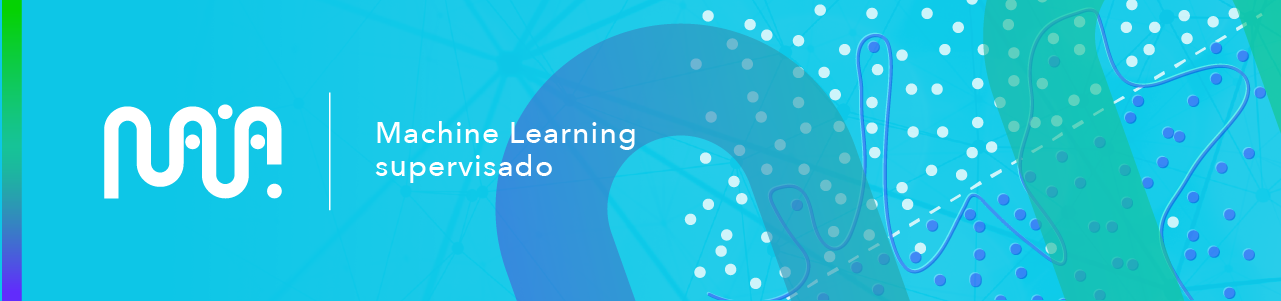

# **Taller semana 7:** Problemas desbalanceados

**Semana 7 - Taller sumativo -** Clasificación de accidentes en maquinaría industrial

**Profesor:** *Fernando Lozano* - **Autor Notebook:** *Daniel López*

# Introducción

En este taller trataremos un problema de clasificación desbalanceado. Se trata de un sistema de detección de fallas mecánicas en maquinaría industrial. 

## Descripcción

Este *jupyter notebook* contiene el material necesario para el desarrollo del Taller de la Semana 
7 del curso *MLS: Machine learning supervisado*. 

### Objetivos de aprendizaje

1. identificar un problema de clasificación en el que es necesario incluir costos. 
2. Aplicar métodos de muestreo para resolver problemas de clasificación no balanceados y/o con costos.
3. Aplicar métodos de clasificación que incorporan costos en la fase de entrenamiento.


### Teoría

Para abordar un problema de clasificación con clases desbalanceadas se aplican métodos de balanceo para garantizar la correcta generalización del modelo. Estos métodos buscan aproximar la cantidad de datos que se tiene para cada una de las clases del problema. Algunos de estos métodos son:

<br> **Oversampling (Sobremuestreo):** Consiste en duplicar muestras existentes de la clase minoritaria o generar muestras a partir de combinaciones lineales de muestras cercanas.Esto aumenta la cantidad de muestras de la clase minoritaria hasta generar el balance.

<br> **Undersampling (Submuestreo):** En este caso, se eliminan muestras de la clase mayoritaria para igual la cantidad de muestras de la clase minoritaria. De esta manere se genera el balance de las clases.

Adicionalmente, es posible es posible entrenar modelos con pesos para clases. Es decir, que se le puede asignar una importancia mayor a la clase minoritaria para que los modelos la clasifiquen correctamente. Esto aplica por lo general en algoritmos que tienen arboles involucrados, como Random Forest, y XGBoost 

## Problema y conjunto de datos


El conjunto de datos son variables características de máquinas industriales, sin embargo, no tienen descripcción por motivos de privacidad corporativa. El conjunto de datos fué obtenido de:
https://www.kaggle.com/competitions/playground-series-s3e17

*Referencias:* Walter Reade, Ashley Chow. (2023). Binary Classification of Machine Failures. Kaggle. https://kaggle.com/competitions/playground-series-s3e17

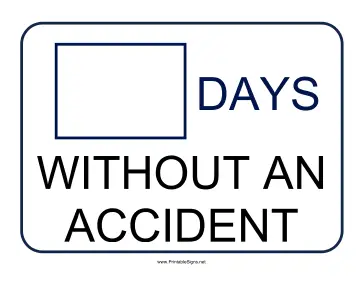

## Metodología

En este cuaderno se realizará una pequeña exploración de datos y se procederá a un ejercicio práctico, donde se realizarán varios modelos basados en árboles en diferentes bases de datos generadas con estrategias de muestreo y submuestreo. Para esto, complete las céldas de código marcadas con el siguiente comentario:

```python
# =====================================================
# COMPLETAR ===========================================
# 

# =====================================================
```

In [1]:
#Importar librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import time
from random import random, seed
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy.stats import uniform, randint
from random import random, seed
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, KFold, cross_validate, cross_val_predict, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score , average_precision_score, f1_score, classification_report, precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import xgboost as xgb
from xgboost.sklearn import XGBClassifier
from xgboost import plot_importance

import warnings # Ignorar las warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.metrics import recall_score, precision_score

In [3]:
df = pd.read_csv('train.csv').drop(['id','Product ID'], axis=1)
df.columns = ['Type', 'Air temperature', 'Process temperature',
       'Rotational speed ', 'Torque ', 'Tool wear ',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

In [4]:
X = df.drop('Machine failure',axis=1)
X = pd.get_dummies(X)
y = df['Machine failure']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=145)

0    0.984256
1    0.015744
Name: Machine failure, dtype: float64


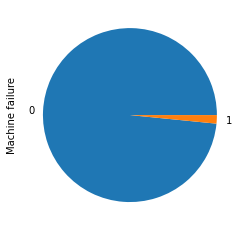

In [6]:
y.value_counts().plot(kind='pie')
print(y.value_counts()/y.shape )

# Ejercicio:

El objetivo de este ejercicio es realizar técnicas de submuestreo y compararlos con modelos que incorporan pesos, así como con modelos sin balancear. Para esto, realizaremos los siguientes pasos:

* Sintonice el algoritmo de XGBoost usando la técnica de RandomizedSearch, optimizando los parámetros Learning Rate, Max depth, n_estimators y reg_lambda. Evalue con datos de prueba, utilice métricas que midan la clasificación de la clase minoritaria.

* Realice la implementación de los algoritmos de submuestreo para los datos correspondientes, posteriormente entrene de nuevo los algoritmos con los datos submuestreados con la mísma técninca de RandomizedSearch. Evalúe en datos de prueba y compare entre los modelos obtenidos hasta el momento.

* Realice la implementacion de los pesos con los métodos vistos anteriormente para los mísmos modelos. Evalúe y compare los resultados de todos los modelos, concluya sobre el mejor modelo para estos datos.

## Entrenamiento base

### XGBoost: Búsqueda aleatoria 

In [7]:
def report_best_scores(results, n_top=3):
    # Esta función espera una instancia de resultados de búsqueda de cross validation, por ejemplo: search.cv_results_
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_accuracy'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_accuracy'][candidate],
                  results['std_test_accuracy'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")
    # Retorna los parámetros del mejor modelo basado en accuracy.
    return list(results.sort_values("rank_test_accuracy")['params'])[0]

def see_results(results):
    # Esta función espera una instancia de pandas dataframe de los resultados de búsqueda de cross validation, por ejemplo: pd.DataFrame(search.cv_results_)
    display(results[results.columns.drop(list(results.filter(regex='split')))].sort_values("rank_test_accuracy"))

In [8]:
# =====================================================
# COMPLETAR ===========================================
# 
# Realize la búsqueda aleatoria. Ayuda: Guiese por la búsqueda realizada en anteriores lecciones
# your code here

# Inicializar el modelo xgboost:
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=145, n_jobs=-1)


# Búsqueda de hiperparámetros:
param_dist = {
    "learning_rate": uniform(0.01, 0.3),   
    "max_depth": randint(3, 10),           
    "n_estimators": randint(50, 300),      
    "reg_lambda": uniform(0, 5)            
}

# Configuración búsqueda aleatoria
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=30,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1'
    },
    refit='accuracy',   
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Entrenar búsqueda
start_search = time.time()
search.fit(X_train, y_train)
end_search = time.time()

# Mostrar mejores resultados directamente
print("\n=== Mejor búsqueda de hiperparámetros ===")
print("Mejor F1 CV:", search.best_score_)
print("Mejores parámetros:", search.best_params_)
print("Tiempo de búsqueda: {:.2f} seg".format(end_search - start_search))

# =====================================================
resultados = pd.DataFrame(search.cv_results_)
see_results(resultados)
best_model_params = report_best_scores(resultados)
best_model_params

Fitting 3 folds for each of 30 candidates, totalling 90 fits

=== Mejor búsqueda de hiperparámetros ===
Mejor F1 CV: 0.996225135830974
Mejores parámetros: {'learning_rate': 0.01691872751242473, 'max_depth': 5, 'n_estimators': 108, 'reg_lambda': 1.9993048585762774}
Tiempo de búsqueda: 568.87 seg


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_reg_lambda,params,mean_test_accuracy,...,rank_test_accuracy,mean_test_precision,std_test_precision,rank_test_precision,mean_test_recall,std_test_recall,rank_test_recall,mean_test_f1,std_test_f1,rank_test_f1
12,4.752000,0.116264,0.090935,0.000672,0.0147899,4,133,1.20513,"{'learning_rate': 0.014789875666064259, 'max_d...",0.996225,...,1,0.993320,0.001712,1,0.767735,0.014226,29,0.865992,0.008507,3
6,4.347823,0.008177,0.097839,0.000376,0.0169187,5,108,1.9993,"{'learning_rate': 0.01691872751242473, 'max_de...",0.996225,...,1,0.993320,0.001712,1,0.767735,0.014226,29,0.865992,0.008507,3
10,5.822373,0.078270,0.100879,0.000375,0.214092,3,216,0.0663248,"{'learning_rate': 0.2140922615763339, 'max_dep...",0.996188,...,3,0.980328,0.000363,16,0.775805,0.015038,10,0.866079,0.009565,2
24,3.510492,0.018360,0.090608,0.002267,0.223403,5,82,3.0298,"{'learning_rate': 0.223402585824595, 'max_dept...",0.996188,...,3,0.987447,0.003699,4,0.770037,0.009996,22,0.865256,0.006550,5
7,13.193092,0.153071,0.247388,0.046622,0.0239997,6,257,1.16386,"{'learning_rate': 0.023999698964084628, 'max_d...",0.996188,...,3,0.989620,0.002010,3,0.768311,0.013421,27,0.864964,0.008363,7
21,5.531806,0.055809,0.103059,0.004370,0.172809,3,206,4.01098,"{'learning_rate': 0.17280882494747454, 'max_de...",0.996188,...,3,0.987446,0.002008,5,0.770039,0.012359,20,0.865236,0.007714,6
4,8.370116,0.016046,0.138292,0.000844,0.291566,4,241,4.96106,"{'learning_rate': 0.29156581270472504, 'max_de...",0.996188,...,3,0.980426,0.004370,15,0.775804,0.013666,11,0.866091,0.006928,1
25,3.149995,0.032307,0.079847,0.003729,0.28789,4,90,4.5748,"{'learning_rate': 0.2878902635540047, 'max_dep...",0.996179,...,8,0.987435,0.002023,6,0.769461,0.010779,23,0.864881,0.006734,8
9,4.866016,0.037338,0.092163,0.002392,0.304969,3,180,4.2997,"{'learning_rate': 0.3049692657420365, 'max_dep...",0.996161,...,9,0.983142,0.005066,12,0.771767,0.011889,17,0.864666,0.007633,9
22,3.849872,0.095975,0.097500,0.007425,0.0323652,9,58,3.86122,"{'learning_rate': 0.032365193103931246, 'max_d...",0.996161,...,9,0.986744,0.003419,7,0.768887,0.013733,24,0.864207,0.007740,11


Model with rank: 1
Mean validation score: 0.996 (std: 0.000)
Parameters: {'learning_rate': 0.01691872751242473, 'max_depth': 5, 'n_estimators': 108, 'reg_lambda': 1.9993048585762774}

Model with rank: 1
Mean validation score: 0.996 (std: 0.000)
Parameters: {'learning_rate': 0.014789875666064259, 'max_depth': 4, 'n_estimators': 133, 'reg_lambda': 1.2051273301300585}

Model with rank: 3
Mean validation score: 0.996 (std: 0.000)
Parameters: {'learning_rate': 0.29156581270472504, 'max_depth': 4, 'n_estimators': 241, 'reg_lambda': 4.961057796456087}

Model with rank: 3
Mean validation score: 0.996 (std: 0.000)
Parameters: {'learning_rate': 0.023999698964084628, 'max_depth': 6, 'n_estimators': 257, 'reg_lambda': 1.1638567021515211}

Model with rank: 3
Mean validation score: 0.996 (std: 0.000)
Parameters: {'learning_rate': 0.2140922615763339, 'max_depth': 3, 'n_estimators': 216, 'reg_lambda': 0.06632480579933264}

Model with rank: 3
Mean validation score: 0.996 (std: 0.000)
Parameters: {'lear

{'learning_rate': 0.014789875666064259,
 'max_depth': 4,
 'n_estimators': 133,
 'reg_lambda': 1.2051273301300585}

#### XGBoost: Entrenamiento y evaluación con mejores parámetros

In [9]:
# =====================================================
# COMPLETAR ===========================================
# 
# Entrenamiento
# your code here

# Crear copia de los mejores parámetros
best_params = best_model_params.copy()
best_params.update({
    "use_label_encoder": False,
    "eval_metric": "logloss",
    "random_state": 145,
    "n_jobs": -1
})

# Entrenar modelo con los mejores parámetros
best_xgb = XGBClassifier(**best_params)
best_xgb.fit(X_train, y_train)
# =====================================================

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.014789875666064259,
              max_bin=256, max_cat_to_onehot=4, max_delta_step=0, max_depth=4,
              max_leaves=0, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=133, n_jobs=-1,
              num_parallel_tree=1, predictor='auto', random_state=145,
              reg_alpha=0, reg_lambda=1.2051273301300585, ...)

In [11]:
# =====================================================
# COMPLETAR ===========================================
# 
#Evaluación

# your code here
# Identificar la etiqueta minoritaria en los datos de entrenamiento
minor_label = y_train.value_counts().idxmin()

# Predicciones sobre el test
y_pred = best_xgb.predict(X_test)

print("=== Evaluación XGBoost con mejores parámetros ===")
print("Etiqueta minoritaria:", minor_label)
print("Precision (minority):", precision_score(y_test, y_pred, pos_label=minor_label))
print("Recall (minority):", recall_score(y_test, y_pred, pos_label=minor_label))
print("F1 (minority):", f1_score(y_test, y_pred, pos_label=minor_label))
print("\nClassification report completo:\n", classification_report(y_test, y_pred))
# =====================================================

=== Evaluación XGBoost con mejores parámetros ===
Etiqueta minoritaria: 1
Precision (minority): 0.9871794871794872
Recall (minority): 0.7457627118644068
F1 (minority): 0.8496551724137931

Classification report completo:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     26873
           1       0.99      0.75      0.85       413

    accuracy                           1.00     27286
   macro avg       0.99      0.87      0.92     27286
weighted avg       1.00      1.00      1.00     27286



### Submuestreo

In [17]:
# =====================================================
# COMPLETAR ===========================================
# 

# your code here
# Aplicar submuestreo al conjunto de entrenamiento
rus = RandomUnderSampler(random_state=145)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print("Distribución original:", np.bincount(y_train))
print("Distribución tras submuestreo:", np.bincount(y_train_res))


# =====================================================

Distribución original: [107408   1735]
Distribución tras submuestreo: [1735 1735]


### Selección de modelo

#### XGBoost con datos submuestreados

In [18]:
# =====================================================
# COMPLETAR ===========================================
# 
# Realize la búsqueda aleatoria. Ayuda: Guiese por la búsqueda realizada en anteriores lecciones
# your code here

xgb_sub = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=145)

param_dist_sub = {
    "learning_rate": uniform(0.01, 0.3),   
    "max_depth": randint(3, 10),           
    "n_estimators": randint(50, 300),      
    "reg_lambda": uniform(0, 5)            
}

# ejecutar RandomizedSearchCV sobre X_train_res, y_train_res
search_sub = RandomizedSearchCV(
    estimator=xgb_sub,
    param_distributions=param_dist_sub,
    n_iter=40,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1'
    },
    refit='accuracy',    
    cv=3,
    n_jobs=-1,
    random_state=145,
    verbose=1,
    return_train_score=True
)

search_sub.fit(X_train_res, y_train_res)

# =====================================================
resultados = pd.DataFrame(search_sub.cv_results_)
see_results(resultados)
best_model_under = report_best_scores(resultados)
best_model_under

Fitting 3 folds for each of 40 candidates, totalling 120 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_reg_lambda,params,mean_test_accuracy,...,mean_test_recall,std_test_recall,rank_test_recall,mean_train_recall,std_train_recall,mean_test_f1,std_test_f1,rank_test_f1,mean_train_f1,std_train_f1
31,0.565230,0.030446,0.013255,0.003524,0.0727311,5,156,1.49417,"{'learning_rate': 0.07273112028954631, 'max_de...",0.915270,...,0.876084,0.004875,26,0.908646,0.005383,0.911908,0.010614,1,0.947124,0.003457
26,0.229757,0.001039,0.008595,0.000108,0.174262,3,82,1.84589,"{'learning_rate': 0.17426172588783778, 'max_de...",0.914982,...,0.873775,0.007064,30,0.887031,0.007555,0.911376,0.011060,3,0.930033,0.003993
24,0.888677,0.004128,0.011940,0.000137,0.0818337,4,295,2.41511,"{'learning_rate': 0.08183367014921132, 'max_de...",0.914695,...,0.878965,0.003637,21,0.922478,0.002289,0.911581,0.006722,2,0.955521,0.001557
6,0.348749,0.004990,0.009607,0.000052,0.0595933,6,87,3.1768,"{'learning_rate': 0.05959331945335982, 'max_de...",0.914694,...,0.867437,0.003466,37,0.889915,0.010559,0.910537,0.009449,5,0.935301,0.004703
8,0.188132,0.004953,0.009053,0.001117,0.157501,3,63,0.438762,"{'learning_rate': 0.1575009771280682, 'max_dep...",0.914694,...,0.870898,0.007168,34,0.886167,0.009215,0.910826,0.009263,4,0.930526,0.006213
17,0.798602,0.018909,0.011331,0.000462,0.0284794,4,255,0.902557,"{'learning_rate': 0.02847942835855155, 'max_de...",0.914406,...,0.866862,0.005013,38,0.886456,0.010079,0.910211,0.010553,7,0.931104,0.004735
9,0.630001,0.002223,0.010045,0.000023,0.0680666,3,239,2.00354,"{'learning_rate': 0.06806658685492102, 'max_de...",0.914118,...,0.872624,0.004504,31,0.889914,0.008503,0.910455,0.009441,6,0.932771,0.005758
36,0.525275,0.035585,0.012184,0.002256,0.0537644,6,125,1.79538,"{'learning_rate': 0.05376439091466591, 'max_de...",0.913830,...,0.870896,0.003469,35,0.902306,0.004276,0.910043,0.009648,8,0.943780,0.001176
0,0.594299,0.006654,0.011138,0.000034,0.0949126,5,173,2.65289,"{'learning_rate': 0.094912584299963, 'max_dept...",0.912965,...,0.877810,0.003545,23,0.921614,0.002150,0.909830,0.007609,9,0.954199,0.001413
7,0.668250,0.023632,0.011081,0.000394,0.0507855,4,216,4.6865,"{'learning_rate': 0.0507855139907094, 'max_dep...",0.912964,...,0.872048,0.006116,32,0.891355,0.007923,0.909325,0.011291,13,0.933014,0.004342


Model with rank: 1
Mean validation score: 0.915 (std: 0.011)
Parameters: {'learning_rate': 0.07273112028954631, 'max_depth': 5, 'n_estimators': 156, 'reg_lambda': 1.4941747439954671}

Model with rank: 2
Mean validation score: 0.915 (std: 0.011)
Parameters: {'learning_rate': 0.17426172588783778, 'max_depth': 3, 'n_estimators': 82, 'reg_lambda': 1.8458889478153324}

Model with rank: 3
Mean validation score: 0.915 (std: 0.007)
Parameters: {'learning_rate': 0.08183367014921132, 'max_depth': 4, 'n_estimators': 295, 'reg_lambda': 2.4151127142758466}



{'learning_rate': 0.07273112028954631,
 'max_depth': 5,
 'n_estimators': 156,
 'reg_lambda': 1.4941747439954671}

#### XGBoost con submuestreo: Entrenamiento y evaluación con mejores parámetros

In [19]:
# =====================================================
# COMPLETAR ===========================================
# 
# Entrenamiento
# your code here
# Entrenamiento con los mejores parámetros encontrados en search_sub
best_params_sub = list(pd.DataFrame(search_sub.cv_results_).sort_values("rank_test_accuracy")['params'])[0]
# Asegurar parámetros necesarios
best_params_sub.update({"use_label_encoder": False, "eval_metric": "logloss", "random_state": 145})

best_xgb_sub = XGBClassifier(**best_params_sub)
best_xgb_sub.fit(X_train_res, y_train_res)
# =====================================================

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.07273112028954631,
              max_bin=256, max_cat_to_onehot=4, max_delta_step=0, max_depth=5,
              max_leaves=0, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=156, n_jobs=0,
              num_parallel_tree=1, predictor='auto', random_state=145,
              reg_alpha=0, reg_lambda=1.4941747439954671, ...)

In [20]:
# =====================================================
# COMPLETAR ===========================================
# 
# Evaluación
# your code here
# Evaluación
minor_label = y_train.value_counts().idxmin()  
y_pred_sub = best_xgb_sub.predict(X_test)

print("Evaluación XGBoost (entrenado con submuestreo) — etiqueta minoritaria:", minor_label)
print("Precision (minority):", precision_score(y_test, y_pred_sub, pos_label=minor_label))
print("Recall (minority):", recall_score(y_test, y_pred_sub, pos_label=minor_label))
print("F1 (minority):", f1_score(y_test, y_pred_sub, pos_label=minor_label))
print("\nClassification report completo:\n", classification_report(y_test, y_pred_sub))
# =====================================================

Evaluación XGBoost (entrenado con submuestreo) — etiqueta minoritaria: 1
Precision (minority): 0.22808132147395171
Recall (minority): 0.8692493946731235
F1 (minority): 0.36134876698540513

Classification report completo:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98     26873
           1       0.23      0.87      0.36       413

    accuracy                           0.95     27286
   macro avg       0.61      0.91      0.67     27286
weighted avg       0.99      0.95      0.97     27286



### Conclusiones

#### Comparación preliminar de modelos (sin balanceo vs. submuestreo)

Hasta el momento hemos entrenado y evaluado dos variantes de XGBoost:  
1. **XGBoost sin balancear** (usando los mejores hiperparámetros encontrados).  
2. **XGBoost con submuestreo aleatorio de la clase mayoritaria** (para equilibrar el dataset respecto a la clase minoritaria).

Los resultados en datos de prueba se resumen a continuación:

| Modelo                     | Accuracy | Precisión (minority) | Recall (minority) | F1 (minority) |
|-----------------------------|----------|-----------------------|-------------------|---------------|
| XGBoost sin balancear       | 1.00     | 0.99                  | 0.75              | 0.85          |
| XGBoost con submuestreo     | 0.95     | 0.23                  | 0.87              | 0.36          |

### Observaciones
- El **modelo sin balancear** logra una precisión muy alta en la clase minoritaria (casi todos los positivos que predice son correctos), pero su **recall** es limitado (75%), lo que implica que deja escapar cerca del 25% de los casos positivos.
- El **modelo con submuestreo** mejora mucho el **recall** (87%), es decir, detecta la mayoría de los positivos reales. Sin embargo, sacrifica la **precisión** drásticamente (0.23), lo que genera muchas falsas alarmas y reduce el F1 a 0.36.
- Existe un **trade-off entre precisión y recall**: uno de los modelos es conservador y preciso, mientras que el otro es más sensible pero menos confiable.

Ahora en el siguiente paso será evaluar el modelo **XGBoost con pesos**, para analizar si se logra un balance más favorable entre precisión y recall en la clase minoritaria.


## Implementación de pesos


### XGBoost

In [24]:
# =====================================================
# COMPLETAR ===========================================
# 
# Entrenamiento con pesos
# your code here
# Calcular el peso (formula: #negativos / #positivos) para scale_pos_weight
minor_label = y_train.value_counts().idxmin()
neg_count = sum(y_train != minor_label)
pos_count = sum(y_train == minor_label)
scale_pos_weight = float(neg_count) / (pos_count + 1e-9)

print("scale_pos_weight a usar:", scale_pos_weight)

# Crear XGB con scale_pos_weight y lanzar RandomizedSearchCV (mismos rangos que antes)
xgb_w = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=145,
                      scale_pos_weight=scale_pos_weight)

param_dist_w = {
    "learning_rate": uniform(0.01, 0.29),
    "max_depth": randint(3, 11),
    "n_estimators": randint(50, 501),
    "reg_lambda": uniform(0.0, 5.0)
}

search_w = RandomizedSearchCV(
    estimator=xgb_w,
    param_distributions=param_dist_w,
    n_iter=40,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1'
    },
    refit='accuracy',   
    cv=3,
    n_jobs=-1,
    random_state=145,
    verbose=1,
    return_train_score=True
)

search_w.fit(X_train, y_train)
# =====================================================
resultados = pd.DataFrame(search_w.cv_results_)
see_results(resultados)
best_params_w = report_best_scores(resultados)
best_params_w

scale_pos_weight a usar: 61.90662824203925
Fitting 3 folds for each of 40 candidates, totalling 120 fits


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,param_reg_lambda,params,mean_test_accuracy,...,mean_test_recall,std_test_recall,rank_test_recall,mean_train_recall,std_train_recall,mean_test_f1,std_test_f1,rank_test_f1,mean_train_f1,std_train_f1
39,31.059471,0.127935,0.565063,0.001631,0.2532,8,457,4.00445,"{'learning_rate': 0.25320017578934534, 'max_de...",0.995318,...,0.793094,0.012478,37,1.000000,0.000000e+00,0.843378,0.006283,1,0.993559,0.001209
24,20.321690,0.353816,0.405817,0.039435,0.182323,8,301,0.83302,"{'learning_rate': 0.18232331964330153, 'max_de...",0.995281,...,0.793095,0.013969,36,1.000000,0.000000e+00,0.842357,0.009035,2,0.990440,0.001444
30,28.214818,0.285899,0.490346,0.030915,0.26964,7,475,1.18503,"{'learning_rate': 0.269640484356722, 'max_dept...",0.995245,...,0.794821,0.010041,31,1.000000,0.000000e+00,0.841646,0.007244,3,0.994271,0.001454
27,34.359948,0.401575,0.680869,0.014555,0.117062,10,404,1.67914,"{'learning_rate': 0.11706155897328926, 'max_de...",0.995236,...,0.790789,0.013290,40,1.000000,0.000000e+00,0.840665,0.008512,4,0.991004,0.000604
29,27.000380,0.132526,0.460200,0.003036,0.288379,7,457,0.184041,"{'learning_rate': 0.2883787303727255, 'max_dep...",0.995226,...,0.791363,0.010038,39,1.000000,0.000000e+00,0.840541,0.008550,5,0.994698,0.001124
4,39.141363,0.171015,0.740012,0.000692,0.0605114,10,440,0.342096,"{'learning_rate': 0.06051138202979912, 'max_de...",0.995153,...,0.792519,0.014563,38,1.000000,0.000000e+00,0.838642,0.009516,6,0.988043,0.001506
9,19.746694,0.113677,0.351926,0.007114,0.220692,7,346,1.37127,"{'learning_rate': 0.22069171924986714, 'max_de...",0.995107,...,0.793668,0.010422,35,1.000000,0.000000e+00,0.837620,0.006004,7,0.989732,0.000919
7,22.724598,0.307762,0.391672,0.010643,0.264898,7,379,3.07494,"{'learning_rate': 0.26489819891323146, 'max_de...",0.995043,...,0.794246,0.012134,34,1.000000,0.000000e+00,0.835937,0.006395,8,0.990864,0.001446
33,18.472034,0.117680,0.322860,0.010445,0.206422,7,312,1.72818,"{'learning_rate': 0.20642164523995, 'max_depth...",0.995034,...,0.794247,0.013293,33,1.000000,0.000000e+00,0.835672,0.005097,9,0.985936,0.000686
3,14.118574,0.128751,0.277998,0.000933,0.15365,10,159,2.86348,"{'learning_rate': 0.15364991089617772, 'max_de...",0.994759,...,0.794248,0.014496,32,1.000000,0.000000e+00,0.828130,0.009065,10,0.977741,0.000969


Model with rank: 1
Mean validation score: 0.995 (std: 0.000)
Parameters: {'learning_rate': 0.25320017578934534, 'max_depth': 8, 'n_estimators': 457, 'reg_lambda': 4.004454296175842}

Model with rank: 2
Mean validation score: 0.995 (std: 0.000)
Parameters: {'learning_rate': 0.18232331964330153, 'max_depth': 8, 'n_estimators': 301, 'reg_lambda': 0.8330197798820221}

Model with rank: 3
Mean validation score: 0.995 (std: 0.000)
Parameters: {'learning_rate': 0.269640484356722, 'max_depth': 7, 'n_estimators': 475, 'reg_lambda': 1.1850326830814644}



{'learning_rate': 0.25320017578934534,
 'max_depth': 8,
 'n_estimators': 457,
 'reg_lambda': 4.004454296175842}

In [25]:
# =====================================================
# COMPLETAR ===========================================
# 
# Evaluación con pesos
# your code here
best_params_w = list(pd.DataFrame(search_w.cv_results_).sort_values("rank_test_accuracy")['params'])[0]
best_params_w.update({"use_label_encoder": False, "eval_metric": "logloss", "random_state": 42, "scale_pos_weight": scale_pos_weight})

best_xgb_w = XGBClassifier(**best_params_w)
best_xgb_w.fit(X_train, y_train)

y_pred_w = best_xgb_w.predict(X_test)

minor_label = y_train.value_counts().idxmin()
print("Evaluación XGBoost (con pesos) — etiqueta minoritaria:", minor_label)
print("Precision (minority):", precision_score(y_test, y_pred_w, pos_label=minor_label))
print("Recall (minority):", recall_score(y_test, y_pred_w, pos_label=minor_label))
print("F1 (minority):", f1_score(y_test, y_pred_w, pos_label=minor_label))
print("\nClassification report completo:\n", classification_report(y_test, y_pred_w))
# =====================================================

Evaluación XGBoost (con pesos) — etiqueta minoritaria: 1
Precision (minority): 0.9051724137931034
Recall (minority): 0.7627118644067796
F1 (minority): 0.8278580814717477

Classification report completo:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     26873
           1       0.91      0.76      0.83       413

    accuracy                           1.00     27286
   macro avg       0.95      0.88      0.91     27286
weighted avg       0.99      1.00      0.99     27286



YOUR ANSWER HERE

## Comparación de Modelos

| Modelo                         | Accuracy | Precisión (minority) | Recall (minority) | F1 (minority) |
|--------------------------------|----------|-----------------------|-------------------|---------------|
| XGBoost sin balanceo           | 1.00     | 0.99                  | 0.75              | 0.85          |
| XGBoost con submuestreo        | 0.95     | 0.23                  | 0.87              | 0.36          |
| XGBoost con pesos (scale_pos_weight) | 0.995    | 0.91                  | 0.76              | 0.83          |


## Análisis y Conclusión

1. **XGBoost sin balanceo**  
   - Presenta una *accuracy* perfecta y una **precisión muy alta (0.99)** en la clase minoritaria.  
   - Sin embargo, su *recall* es más bajo (0.75), lo que significa que el modelo deja escapar alrededor del **25% de los casos positivos reales**.  
   - Esto refleja un sesgo hacia la clase mayoritaria: clasifica bien los pocos positivos que reconoce, pero ignora varios de ellos.  
   

2. **XGBoost con submuestreo**  
   - Mejora mucho el *recall* (0.87), detectando la mayoría de los positivos.  
   - El problema es que pierde gran parte de la precisión (0.23), generando demasiados falsos positivos.  
   - Como consecuencia, el F1 cae drásticamente a 0.36, lo que muestra que el modelo es poco útil en la práctica pese a identificar más positivos.  
   

3. **XGBoost con pesos (scale_pos_weight)**  
   - Mantiene un desempeño muy similar al modelo sin balanceo, con un *recall* ligeramente mejor (0.76 vs 0.75).  
   - La precisión baja un poco (0.91 vs 0.99), pero sigue siendo muy alta.  
   - El F1 (0.83) se mantiene prácticamente al nivel del modelo sin balanceo (0.85), pero con la ventaja de que el modelo está **explícitamente balanceado**, es decir, no depende de la distribución de clases para lograrlo.  

---

###  Conclusión final
- **El submuestreo** no resulta competitivo: aunque incrementa el recall, sacrifica demasiado la precisión y el F1.  
- **El modelo sin balanceo** ofrece un muy buen desempeño, pero muestra cierta tendencia a ignorar casos minoritarios (recall limitado).  
- **El modelo con pesos** logra un **equilibrio más confiable**, manteniendo resultados muy cercanos al modelo sin balanceo pero con la ventaja de ser más **robusto y justo con la clase minoritaria**, gracias al uso de `scale_pos_weight`.  

Por lo tanto, el **mejor modelo** para este problema es **XGBoost con pesos**, ya que logra un balance adecuado entre precisión y recall de la clase minoritaria sin perder exactitud global.  